# Kelman Filtering

In [1]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

# Add the libs directory to Python path
current_dir = os.path.dirname(os.path.abspath('KelmanFiltering.ipynb'))
libs_dir = os.path.join(current_dir, '..', 'libs')
libs_dir = os.path.abspath(libs_dir)
print("Libs directory:", libs_dir)
sys.path.insert(0, libs_dir)

from websocketclient import WebSocketCollector
from kelmanfilter import KalmanFilter


Matplotlib is building the font cache; this may take a moment.


Libs directory: /Users/kolithawarnakulasooriya/Projects/AI-driven-cyber-physical-system/libs


In [7]:
ws_url = "ws://localhost:8000/ws"
message_queue = WebSocketCollector(ws_url, max_messages=1000).collect()
print("Collected messages:", message_queue.qsize())

WebSocket opened
WebSocket closed
Collected messages: 1000


In [8]:
print("Sample message:", message_queue.get())

raw_values = [message_queue.get() for _ in range(message_queue.qsize())]
values = [json.loads(value).get("data").get("value") for value in raw_values]
values = [float(value) for value in values if value is not None]
print("Extracted values:", values)

Sample message: {"type": "initial_state", "data": {"sensors": [{"id": "65a83e65-77a9-4ccc-bdb3-729a544c9ca5", "name": "Sensor1", "type": "gaussian", "interval": 0.1, "min_value": 0, "max_value": 100, "is_running": false, "current_value": 64.20985638608146, "recording": false, "parameters": {}}, {"id": "8bf1d5f5-ae0b-4e79-bd11-690b8e70ab06", "name": "S3", "type": "lidar", "interval": 0.01, "min_value": 0, "max_value": 100, "is_running": true, "current_value": 87.37786727250727, "recording": false, "parameters": {}}], "mqtt_connected": false, "recordings": {}}}
Extracted values: [80.46450244316124, 79.05343581207022, 81.15013646556942, 82.09036944732168, 78.80044376860138, 82.84792151150064, 84.54592168063243, 80.57615782898483, 85.32998946325566, 87.11987005896462, 79.04919861177277, 83.4337359168166, 77.5971631231449, 75.20464663016357, 75.03540962948068, 77.48775938820266, 88.81315439599061, 99.03747892650314, 91.08937793595643, 94.24569837705539, 99.71421633588305, 100.0, 100.0, 99.7

In [10]:
# Enhanced Kalman filter using class
if 'values' in locals() and values:
    # Use advanced Kalman filter with velocity estimation
    kf = KalmanFilter(dt=1.0, 
                       process_variance=1e-5, 
                       measurement_variance=1e-2,
                       initial_position=values[0],
                       initial_velocity=0.0)
    
    filtered_values, velocities = kf.filter(values)
    
    print("=== Kalman Filter Results ===")
    print(f"Raw values (first 10): {values[:10]}")
    print(f"Filtered values (first 10): {[f'{v:.4f}' for v in filtered_values[:10]]}")
    print(f"Estimated velocities (first 10): {[f'{v:.4f}' for v in velocities[:10]]}")
    print(f"Mean squared error (Filter vs Raw): {np.mean([(f - r)**2 for f, r in zip(filtered_values, values)]):.6f}")


=== Kalman Filter Results ===
Raw values (first 10): [80.46450244316124, 79.05343581207022, 81.15013646556942, 82.09036944732168, 78.80044376860138, 82.84792151150064, 84.54592168063243, 80.57615782898483, 85.32998946325566, 87.11987005896462]
Filtered values (first 10): ['80.4645', '79.0799', '80.5581', '81.7267', '80.2515', '81.5963', '83.1530', '82.4376', '83.7602', '85.2837']
Estimated velocities (first 10): ['0.0000', '-1.3450', '0.3324', '0.6891', '-0.0311', '0.3449', '0.6267', '0.3539', '0.5297', '0.6938']
Mean squared error (Filter vs Raw): 35.597189


(array([31., 12., 16., 12., 17., 43., 33., 30., 33., 28., 30., 35., 36.,
        44., 55., 55., 63., 65., 55., 45., 22., 19., 24., 27., 30., 28.,
        25., 19., 23., 44.]),
 array([  0.        ,   3.33333333,   6.66666667,  10.        ,
         13.33333333,  16.66666667,  20.        ,  23.33333333,
         26.66666667,  30.        ,  33.33333333,  36.66666667,
         40.        ,  43.33333333,  46.66666667,  50.        ,
         53.33333333,  56.66666667,  60.        ,  63.33333333,
         66.66666667,  70.        ,  73.33333333,  76.66666667,
         80.        ,  83.33333333,  86.66666667,  90.        ,
         93.33333333,  96.66666667, 100.        ]),
 <BarContainer object of 30 artists>)

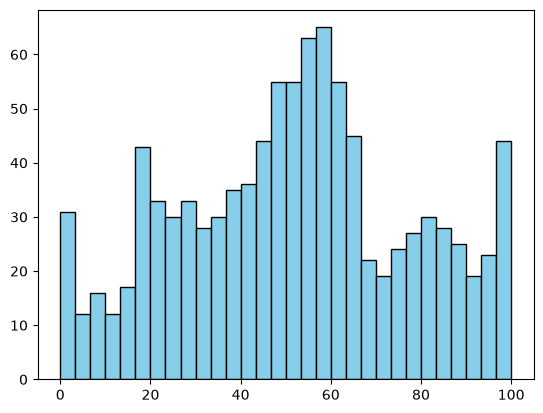

In [11]:
plt.hist(values, bins=30, color='skyblue', edgecolor='black')